## STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

**Interpretation:**
* pandas → data handling
* matplotlib → visualization
* re, string → text cleaning
* CountVectorizer → convert text → numbers
* Naive Bayes → sentiment classification model

## STEP 2: LOAD DATASET

In [2]:
df = pd.read_csv("twitter_training.csv")
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


**Interpretation:**
* Dataset doesn’t have proper column names.
* Need to set column names

In [3]:
df.columns = ['id', 'entity', 'sentiment', 'text']
df.head()

,id,entity,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


**Interpretation:**
* Now this dataset contains proper column names
* Dataset contains:
    * Text (tweets)
    * Sentiment (Positive, Negative, Neutral, Irrelevent)
    * Entities (Topic/Brand)

## STEP 3: BASIC EXPLORATORY DATA ANALYSIS

### 3.1 Check structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74681 non-null  int64 
 1   entity     74681 non-null  object
 2   sentiment  74681 non-null  object
 3   text       73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


**Interpretation:**
* Shows:
    * Data types
    * Missing values
* Important columns:
    * text
    * sentiment

### 3.2 Check missing values

In [5]:
df.isnull().sum()

id             0
entity         0
sentiment      0
text         686
dtype: int64

**Interpretation:**
* Missing text → must remove
* Missing sentiment → cannot train model

### 3.3 Sentiment distribution

In [6]:
df['sentiment'].value_counts()

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

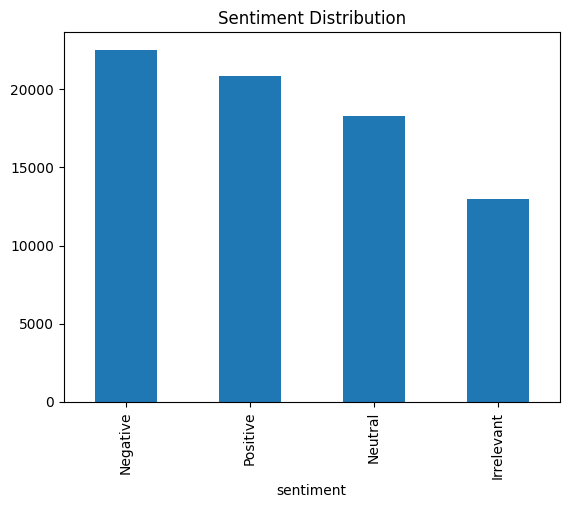

In [7]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

**Interpretation:**
* Shows how many sentiments are:
    * Positive 
    * Negative 
    * Neutral
    * Irrelevant
* Helps detect imbalance

# STEP 4: DATA CLEANING

### 4.1 Remove missing values

In [8]:
df = df.dropna(subset=['text', 'sentiment'])

### 4.2 Text Cleaning Function

In [9]:
def clean_text(text):
    text = text.lower()   # lowercase
    text = re.sub(r'http\S+', '', text)  # remove links
    text = re.sub(r'@\w+', '', text)     # remove mentions
    text = re.sub(r'#', '', text)        # remove hashtags symbol
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    return text

### 4.3 Apply cleaning

In [10]:
df['clean_text'] = df['text'].apply(clean_text)

**Interpretation:**
* Removes noise:
    * URLs
    * special characters
* Makes text ready for analysis

## STEP 5: CONVERT TEXT TO NUMBERS

In [11]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

**Interpretation:**
* Machine learning cannot read text
* Converts words → numerical features

## STEP 6: TRAIN-TEST SPLIT

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Interpretation:**
* 80% training, 20% testing
* Ensures fair evaluation

## STEP 7: BUILD SENTIMENT MODEL

In [13]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

**Interpretation:**
* Model learns:
* Which words → positive/negative sentiment

## STEP 8: MAKE PREDICTIONS

In [14]:
y_pred = model.predict(X_test)

## STEP 9: EVALUATE MODEL

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7310629096560578


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.80      0.57      0.67      2624
    Negative       0.69      0.85      0.76      4463
     Neutral       0.82      0.60      0.69      3589
    Positive       0.70      0.81      0.75      4123

    accuracy                           0.73     14799
   macro avg       0.75      0.71      0.72     14799
weighted avg       0.74      0.73      0.73     14799



**Interpretation:**
* Accuracy → overall performance
* Precision/Recall → class-wise performance

## STEP 10: VISUALIZE SENTIMENT PATTERNS

### 10.1 Sentiment Distribution

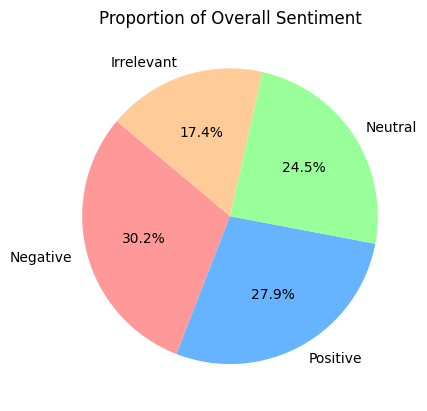

In [17]:
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140,  colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title("Proportion of Overall Sentiment")
plt.ylabel("") # Hides the 'sentiment' label on the y-axis
plt.show()

**Interpretation:**
* Shows overall public opinion

### 10.2 Sentiment by Brand

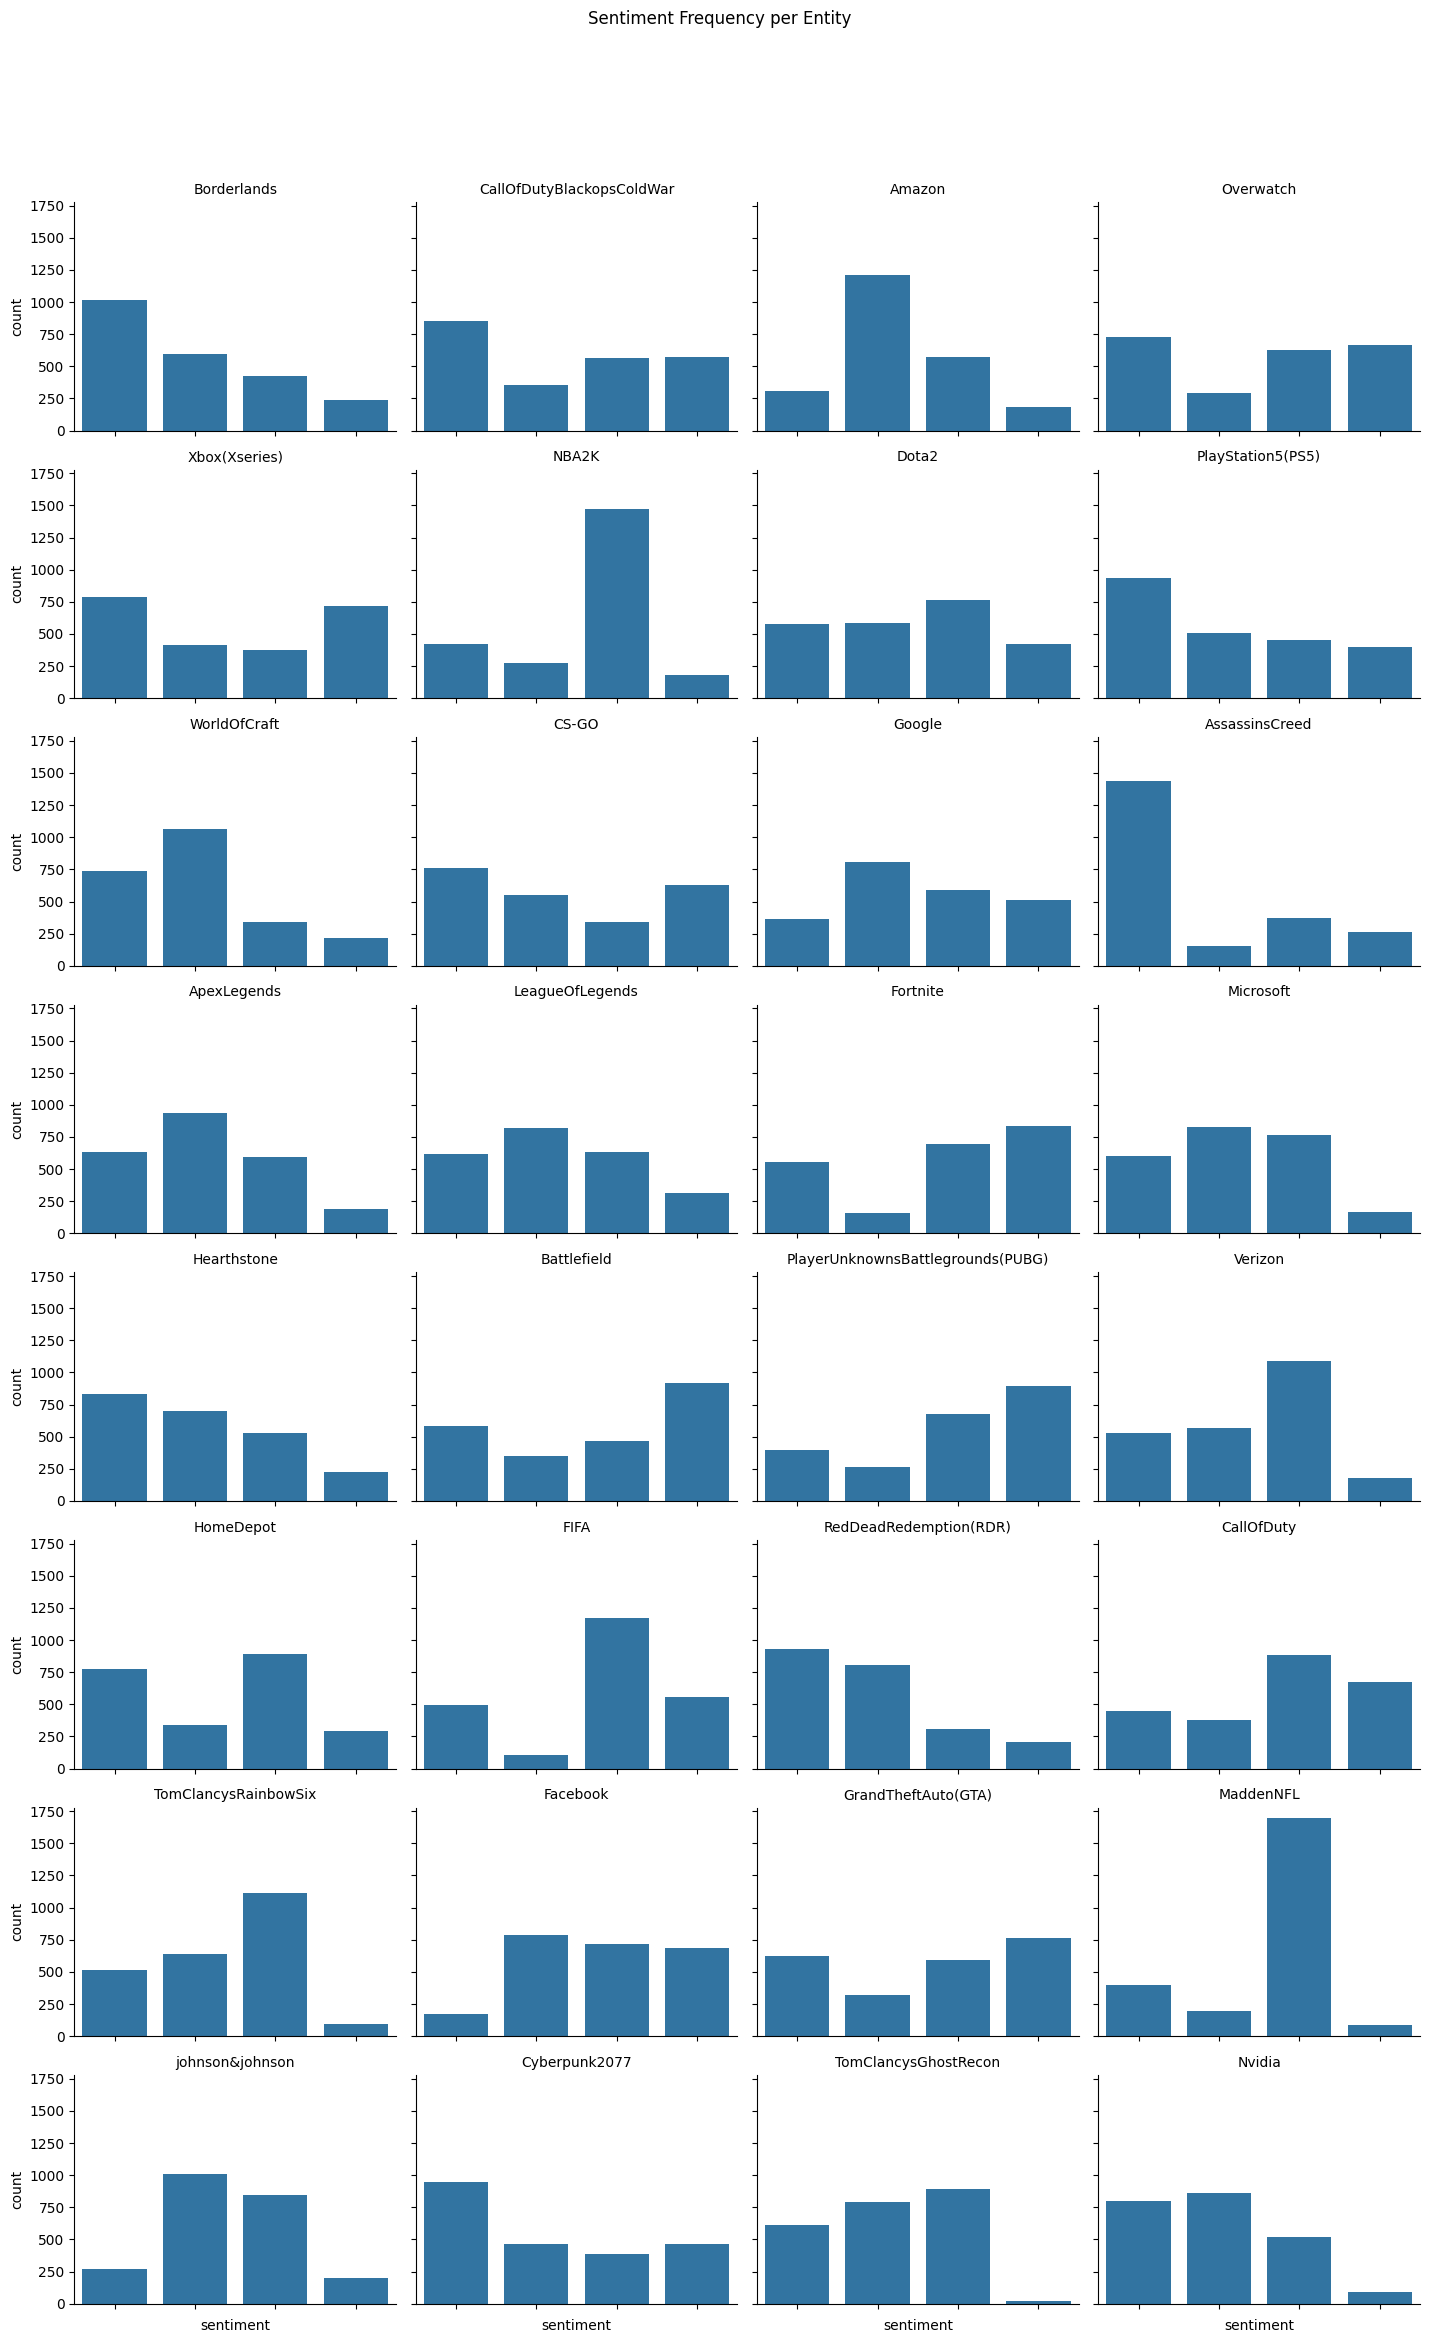

In [18]:
g = sns.catplot(
    data=df, x='sentiment', col='entity', 
    kind='count', col_wrap=4, height=3, aspect=1.2
)
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Sentiment Frequency per Entity')
plt.show()

**Interpretation:**
* Shows:
    * Which brand has more positive sentiment
    * Which has more negative sentiment

## STEP 11: TEST CUSTOM INPUT

In [19]:
sample = ["This product is amazing and I love it"]

sample_clean = [clean_text(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vec)

print("Sentiment:", prediction[0])

Sentiment: Positive


**Interpretation:**
* Model predicts sentiment of new text
* Output:
    * Positive